In [1]:
import pandas as pd

In [2]:
import sys
sys.path.append('/home/evlasova/mirpy')

In [3]:
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA

# Loading data functions
Having run the TCRemPNet pipeline you would get a directory eith the following files for each sample:
* `run_name_background_embeddings.parquet` - TCRemP embeddings of background repertoire in parquet format
* `run_name_sample_embeddings.parquet` - TCRemP embeddings of sample repertoire in parquet format
* `run_name.log` - file with job logs
* `run_name_summary_tcrempnet.tsv` - file with description of each cluster with major metrics 
* `run_name_enriched_clonotypes_tcremp.tsv` - list of clonotype information for all clusters which are significantly enriched
* `run_name_enriched_embeddings_tcremp.tsv` - embedding information for clonotypes from encriched clusters only; the order of embeddings corresponds to the order of clonotypes in `run_name_enriched_clonotypes_tcremp` file

In this section of the notebook we upload the needed objects and vdjdb database (spring'25 release). Here we analyze the data from 6 healthy patients who were vaccinated from YFV. Our aim is to analyze whether the found clusters are associated with YFV vaccination.

In [4]:
def get_sample_info(sample_name):
    data_path = f'/projects/immunestatus/pogorelyy/tcrempnet/{sample_name[:5]}'
    summary = pd.read_csv(f'{data_path}/yfv_{sample_name}_summary_tcrempnet.tsv', sep='\t')
    c0 = len(pd.read_csv(
        f'/projects/immunestatus/pogorelyy/airr_format/{sample_name.split('_')[0]}_0_F1{'_with_1_downsampled' if 'w' in sample_name else ''}.txt', sep='\t'))
    c15 = len(pd.read_csv(
        f'/projects/immunestatus/pogorelyy/airr_format/{sample_name.split('_')[0]}_15_F1.txt', sep='\t'))
    print(f'''
    sample: {sample_name}
    clusters: {len(summary)}
    overall from background: {c0}
    overall from sample: {c15}
    ''')
    return summary, c0, c15

In [5]:
vdjdb_df = pd.read_csv('../../data/vdjdb.slim.txt', sep='\t')

In [6]:
vdjdb_seqs = vdjdb_df[(vdjdb_df['antigen.species'] == 'YFV') & (vdjdb_df['gene'] == 'TRB')].cdr3
vdjdb_clonotypes = [ClonotypeAA(cdr3aa=x) for x in vdjdb_seqs]

In [7]:
vdjdb = ClonotypeDataset(vdjdb_clonotypes)

In [8]:
vdjdb

A dataset of 402 clonotypes and 357 clusters

In [9]:
def get_clonotypes(sample_name):
    data_path = f'/projects/immunestatus/pogorelyy/tcrempnet/{sample_name[:5]}'
    df = pd.read_csv(f'{data_path}/yfv_{sample_name}_with_1_enriched_clonotypes_tcremp.tsv', sep='\t')
    return df

In [10]:
def has_vdjdb_match(x):
    return len(vdjdb.get_matching_clonotypes(x))

def get_cluster_matches_vdjdb(df, cluster_id):
    df = df[df.cluster_id == cluster_id]
    matches = df.cdr3aa_beta.apply(has_vdjdb_match)
    return sum(matches) > 0

# Visualizing individual sample enrichments
In tcrempnet pipeline all the background files (the ones derived from patients on vaccination day) are downsampled to 350k in order to reduce the difference between sample coverages. 

Further, we analyze each tcrempnet cluster and generate two features - pvalue and the fold change of clonotypes in a cluster.

Let's denote `N` and `M` - number of clonotypes in sample and background repertoire we consider during the analysis.
* `log2fc`: consider a cluster of `m + n` clonotypes, where `n` clonotypes come from sample and `m` clonotypes come from background => `log2fc = log2( n/N / m/M)` 
* `pvalue`: denote $p=m/M$ as the probability that a clonotype is assigned to a cluster of interest randomly; in this case, the number of assignments is distributied as a binomial distribtion with parameters `N` (overall number of points) and `p` ($X \sim Bin(N, p)$). Let's use the standard transformation as follows: $Z = (X - EX) / \sigma \sim N(0, 1)$=> $Z=\frac{X-\overline{X}}{\sqrt{DX}}=\frac{Mn-mN}{\sqrt{Nm(M-m)}}\sim N(0, 1)$. Having this statistic of the null hypothesis we can calculate the p-value of the cluster to be randomly assembled. 

The false discovery rate adjustment is applied to the final results to make sure FDR < 0.05.

In [11]:
samples = ['S1_F1', 'S2_F1', 'P1_F1', 'P2_F1', 'Q1_F1', 'Q2_F1']
sample_to_data = {}

for sample in samples:
    info = get_sample_info(sample + '_with_1')
    df = get_clonotypes(sample)
    info[0]['vdjdb'] = info[0].cluster_id.apply(lambda x: get_cluster_matches_vdjdb(df, x))
    sample_to_data[sample] = info



    sample: S1_F1_with_1
    clusters: 16919
    overall from background: 350000
    overall from sample: 139748
    

    sample: S2_F1_with_1
    clusters: 25178
    overall from background: 350000
    overall from sample: 276172
    

    sample: P1_F1_with_1
    clusters: 22461
    overall from background: 350000
    overall from sample: 311112
    

    sample: P2_F1_with_1
    clusters: 25206
    overall from background: 350000
    overall from sample: 362331
    

    sample: Q1_F1_with_1
    clusters: 12073
    overall from background: 350000
    overall from sample: 86750
    

    sample: Q2_F1_with_1
    clusters: 23747
    overall from background: 350000
    overall from sample: 205818
    


In [12]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df, pval_threshold=0.05, fold_threshold=0, ax=None, sample_name='None'):
    df = df.copy()

    if 'vdjdb' not in df.columns:
        raise ValueError("DataFrame должен содержать колонку 'vdjdb'")

    # Преобразования
    df['log10_pval'] = -np.log10(df['enrichment_pvalue_zbinom'] + 1e-10)
    df['log2_fc'] = df['log_fold_change']
    df['significant'] = (df['enrichment_fdr_zbinom'] < pval_threshold) & (df['log2_fc'] > fold_threshold)
    

    # Цветовая кодировка
    def assign_color(row):
        if row['significant'] and row['vdjdb']:
            return 'sign_vdjdb'
        elif row['significant']:
            return 'sign'
        elif row['vdjdb']:
            return 'vdjdb'
        else:
            return 'no'
    
    colors = {
        'sign_vdjdb': '#084594',  # dark blue
        'sign': '#4292c6',  # blue
        'vdjdb': '#fdbb84',  # orange
        'no': '#ffffb2'  # yellow
    }
    
    df['label'] = df.apply(assign_color, axis=1)

    adjustment_thresh = df[df.enrichment_fdr_zbinom < pval_threshold].enrichment_pvalue_zbinom.max()
    log10_adj = -np.log10(adjustment_thresh)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Отрисовка
    sns.scatterplot(
        data=df,
        x='log2_fc',
        y='log10_pval',
        hue='label',
        style='vdjdb',
        palette=colors,
        markers={True: 's', False: '.'},
        edgecolor='black',
        linewidth=0.3,
        ax=ax,
        s=70,
        alpha=0.85,
    )

    # Линии порогов
    ax.axvline(fold_threshold, ls='--', color='black')
    ax.axhline(-np.log10(pval_threshold), ls='--', color='black')
    ax.axhline(log10_adj, ls=':', color='blue')

    ax.set_xlabel('log2(Fold Enrichment)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'{sample_name}, # clusters with FDR<0.05: {df.significant.sum()}')
    ax.legend()

/scratch/ipykernel_3231248/611503398.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


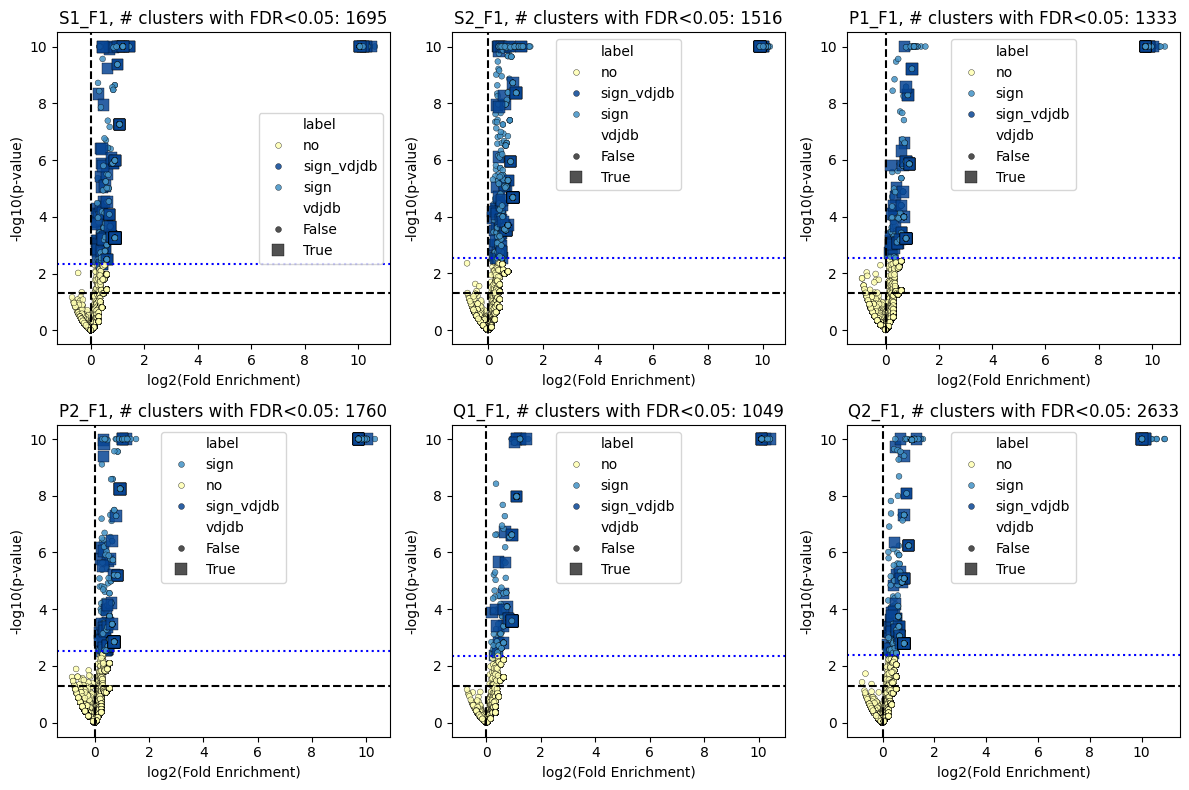

In [13]:
import matplotlib.pyplot as plt
nrows=2
ncols=3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 4), constrained_layout=True)

for i, s in enumerate(samples):
    row, col = divmod(i, ncols)
    ax = axes[row, col]

    s1_res = sample_to_data[s]

    plot_volcano(s1_res[0], ax=ax, fold_threshold=0, sample_name=s)
plt.tight_layout()
plt.show()

# Single sample result evaluation
For all the considered samples we observe a vast number of enriched clusters. The upper-right corner of the volcano plot for each sample includes multiple clusters which match to at least one VDJdb YFV clonotype. Moreover, none of VDJdb YFV clonotypes match to clusters colored with yellow (==insignificant clusters). However, many of the enriched clusters do not match VDJdb which might mean those clusters are specific to other YFV epitopes (VDJdb has records of LLWNGPMAV-specific clonotypes). 

# Public YFV response investigation
The clusters found in the previous steps are specific for each individual patient. We further merge the clusters between patients to find clusters which are publicly found within multiple patients. Currently, two clusters $A$ and $B$ are merged if $A\cap B \neq \emptyset$. Further, we plan to broaden the merging techniques by adding a specific intersection percent, e.t.c. 

Having merged the clusters we result in a set of clusters with clonotypes derived from various samples. We calculate metrics for those clusters and rate them using TOPSIS algorithm.

## 1. Creating a joint list of clusters for all patients
Here we create a joint list of clusters and select clonotypes from all the patients. A joint dataset of clonotypes is created.

In [14]:
all_info = []
for s in samples:
    s_res = sample_to_data[s][0]
    res_df = s_res[['cluster_id', 'vdjdb', 'enrichment_fdr_zbinom', 'log_fold_change']]
    res_df = res_df[(res_df.enrichment_fdr_zbinom < 0.05) & (res_df.log_fold_change > 0)]
    res_df['sample'] = s
    all_info.append(res_df)

In [15]:
joint = pd.concat(all_info)

In [16]:
joint = joint.rename(columns={'log_fold_change': 'fold_enrichment', 'enrichment_fdr_zbinom': 'pvalue'})

In [17]:
joint

,cluster_id,vdjdb,pvalue,fold_enrichment,sample
3,3,True,0.000003,1.070209,S1_F1
4,4,True,0.000067,0.814936,S1_F1
14,14,False,0.000000,10.070209,S1_F1
28,28,False,0.005865,0.894118,S1_F1
29,29,False,0.004285,0.593088,S1_F1
...,...,...,...,...,...
23519,23519,False,0.014928,0.833879,Q2_F1
23521,23521,False,0.014928,0.833879,Q2_F1
23590,23590,False,0.014928,0.833879,Q2_F1
23667,23667,False,0.014928,0.833879,Q2_F1


In [18]:
all_clonotypes_enriched = []
for patient in samples:
    t = get_clonotypes(patient).drop(columns=['enrichment_pvalue_zbinom'])
    t = t[t.cluster_id.isin(joint[joint['sample'] == patient].cluster_id)]
    t['cluster_id'] = patient + '_c' + t.cluster_id.astype(str)
    t['sample_name'] = patient
    all_clonotypes_enriched.append(t)

In [19]:
data = pd.concat(all_clonotypes_enriched)
data

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name
0,s_8,S1_F1_c3,CSGPIAGGPNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,S1_F1
1,s_9,S1_F1_c4,CASSASGDAYEQYF,TRBV9*01,TRBJ2-7*01,sample,S1_F1
2,s_43,S1_F1_c14,CASSTGTRTYEQYF,TRBV28*01,TRBJ2-7*01,sample,S1_F1
3,s_73,S1_F1_c28,CASSLGYSNQPQHF,TRBV12-4*01,TRBJ1-5*01,sample,S1_F1
4,s_75,S1_F1_c29,CSAGGTSYEQYF,TRBV29-1*01,TRBJ2-7*01,sample,S1_F1
...,...,...,...,...,...,...,...
15754,b_701970,Q2_F1_c7235,CSVEGYTF,TRBV29-1*01,TRBJ1-2*01,background,Q2_F1
15755,b_701976,Q2_F1_c7235,CSVAGYTF,TRBV29-1*01,TRBJ1-2*01,background,Q2_F1
15756,b_701977,Q2_F1_c87,CSVETGEF,TRBV29-1*01,TRBJ2-5*01,background,Q2_F1
15757,b_701981,Q2_F1_c87,CSEETQYF,TRBV29-1*01,TRBJ2-5*01,background,Q2_F1


In [20]:
data['vdjdb'] = data.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [21]:
data

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb
0,s_8,S1_F1_c3,CSGPIAGGPNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,S1_F1,False
1,s_9,S1_F1_c4,CASSASGDAYEQYF,TRBV9*01,TRBJ2-7*01,sample,S1_F1,False
2,s_43,S1_F1_c14,CASSTGTRTYEQYF,TRBV28*01,TRBJ2-7*01,sample,S1_F1,False
3,s_73,S1_F1_c28,CASSLGYSNQPQHF,TRBV12-4*01,TRBJ1-5*01,sample,S1_F1,False
4,s_75,S1_F1_c29,CSAGGTSYEQYF,TRBV29-1*01,TRBJ2-7*01,sample,S1_F1,False
...,...,...,...,...,...,...,...,...
15754,b_701970,Q2_F1_c7235,CSVEGYTF,TRBV29-1*01,TRBJ1-2*01,background,Q2_F1,False
15755,b_701976,Q2_F1_c7235,CSVAGYTF,TRBV29-1*01,TRBJ1-2*01,background,Q2_F1,False
15756,b_701977,Q2_F1_c87,CSVETGEF,TRBV29-1*01,TRBJ2-5*01,background,Q2_F1,False
15757,b_701981,Q2_F1_c87,CSEETQYF,TRBV29-1*01,TRBJ2-5*01,background,Q2_F1,False


In [22]:
found_clonotypes = [ClonotypeAA(cdr3aa=x) for x in data.cdr3aa_beta]
dataset = ClonotypeDataset(found_clonotypes)

In [23]:
import networkx as nx
from collections import defaultdict

In [24]:
df = data

## 2. Merging clusters from patients
Here we apply a graph based approach where two vertices of a graph are connected if they have at least one common clonotype. Further, the connected components of a such a graph are extracted and each connected component is a new cluster.

In [25]:
cdr3_to_clusters = defaultdict(set)
for _, row in df.iterrows():
    cdr3_to_clusters[row['cdr3aa_beta']].add(row['cluster_id'])

G = nx.Graph()
G.add_nodes_from(df['cluster_id'].unique())

for clusters in cdr3_to_clusters.values():
    clusters = list(clusters)
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            G.add_edge(clusters[i], clusters[j])

cluster_mapping = {}
for new_id, component in enumerate(nx.connected_components(G)):
    for cluster_id in component:
        cluster_mapping[cluster_id] = new_id

df['merged_cluster_id'] = df['cluster_id'].map(cluster_mapping)

In [26]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id
0,s_8,S1_F1_c3,CSGPIAGGPNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,S1_F1,False,0
1,s_9,S1_F1_c4,CASSASGDAYEQYF,TRBV9*01,TRBJ2-7*01,sample,S1_F1,False,1
2,s_43,S1_F1_c14,CASSTGTRTYEQYF,TRBV28*01,TRBJ2-7*01,sample,S1_F1,False,2
3,s_73,S1_F1_c28,CASSLGYSNQPQHF,TRBV12-4*01,TRBJ1-5*01,sample,S1_F1,False,3
4,s_75,S1_F1_c29,CSAGGTSYEQYF,TRBV29-1*01,TRBJ2-7*01,sample,S1_F1,False,4
...,...,...,...,...,...,...,...,...,...
15754,b_701970,Q2_F1_c7235,CSVEGYTF,TRBV29-1*01,TRBJ1-2*01,background,Q2_F1,False,6399
15755,b_701976,Q2_F1_c7235,CSVAGYTF,TRBV29-1*01,TRBJ1-2*01,background,Q2_F1,False,6399
15756,b_701977,Q2_F1_c87,CSVETGEF,TRBV29-1*01,TRBJ2-5*01,background,Q2_F1,False,186
15757,b_701981,Q2_F1_c87,CSEETQYF,TRBV29-1*01,TRBJ2-5*01,background,Q2_F1,False,186


## 3. Calculating extra information for clusters
Here we calculate calculate generation probability for each clonotype of interest to further create a metrics of the average generation probability within a cluster.
Moreover, we calculate the sample and background fraction for each cluster and calculate from how many various patients the clonotypes come from in each cluster.

In [27]:
from mir.basic.pgen import OlgaModel

In [28]:
olga = OlgaModel()

In [29]:
df['pgen'] = df.cdr3aa_beta.apply(olga.compute_pgen_cdr3aa)

In [30]:
cluster_sizes = df.groupby("merged_cluster_id").size().reset_index(name="cluster_size")

n_patients = df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',
    'vdjdb': 'any', 
    'pgen': 'mean'
}).reset_index().rename(columns={'sample_name': "n_patients"})

source_counts = df.pivot_table(index='merged_cluster_id', columns='source', 
                               values='clone_id', aggfunc='count', fill_value=0).reset_index()

summary = cluster_sizes.merge(n_patients, on="merged_cluster_id")
summary = summary.merge(source_counts, on="merged_cluster_id")

summary['sample_fraction'] = summary.get('sample', 0) / summary['cluster_size']
summary['background_fraction'] = summary.get('background', 0) / summary['cluster_size']

summary = summary.sort_values(by=["n_patients", "cluster_size"], ascending=False)

In [31]:
summary

,merged_cluster_id,cluster_size,n_patients,vdjdb,pgen,background,sample,sample_fraction,background_fraction
35,35,5640,6,False,4.455090e-07,3176,2464,0.436879,0.563121
47,47,2204,6,True,1.112317e-06,1213,991,0.449637,0.550363
186,186,1751,6,True,1.720137e-08,1042,709,0.404911,0.595089
188,188,1740,6,False,1.701140e-08,1018,722,0.414943,0.585057
73,73,1599,6,False,2.165088e-08,927,672,0.420263,0.579737
...,...,...,...,...,...,...,...,...,...
7394,7394,3,1,False,3.678026e-08,1,2,0.666667,0.333333
7395,7395,3,1,False,1.910643e-08,1,2,0.666667,0.333333
7396,7396,3,1,False,1.230608e-10,1,2,0.666667,0.333333
7397,7397,3,1,False,0.000000e+00,1,2,0.666667,0.333333


In [32]:
summary.sort_values(by='cluster_size', ascending=False).head(10)

,merged_cluster_id,cluster_size,n_patients,vdjdb,pgen,background,sample,sample_fraction,background_fraction
35,35,5640,6,False,4.455090e-07,3176,2464,0.436879,0.563121
47,47,2204,6,True,1.112317e-06,1213,991,0.449637,0.550363
100,100,1955,5,True,3.175656e-08,1160,795,0.406650,0.593350
186,186,1751,6,True,1.720137e-08,1042,709,0.404911,0.595089
188,188,1740,6,False,1.701140e-08,1018,722,0.414943,0.585057
73,73,1599,6,False,2.165088e-08,927,672,0.420263,0.579737
45,45,938,6,True,3.039589e-07,559,379,0.404051,0.595949
41,41,877,4,True,5.750864e-09,510,367,0.418472,0.581528
104,104,874,6,True,1.570387e-07,462,412,0.471396,0.528604
53,53,844,4,True,2.333062e-08,472,372,0.440758,0.559242


In [33]:
summary

,merged_cluster_id,cluster_size,n_patients,vdjdb,pgen,background,sample,sample_fraction,background_fraction
35,35,5640,6,False,4.455090e-07,3176,2464,0.436879,0.563121
47,47,2204,6,True,1.112317e-06,1213,991,0.449637,0.550363
186,186,1751,6,True,1.720137e-08,1042,709,0.404911,0.595089
188,188,1740,6,False,1.701140e-08,1018,722,0.414943,0.585057
73,73,1599,6,False,2.165088e-08,927,672,0.420263,0.579737
...,...,...,...,...,...,...,...,...,...
7394,7394,3,1,False,3.678026e-08,1,2,0.666667,0.333333
7395,7395,3,1,False,1.910643e-08,1,2,0.666667,0.333333
7396,7396,3,1,False,1.230608e-10,1,2,0.666667,0.333333
7397,7397,3,1,False,0.000000e+00,1,2,0.666667,0.333333


In [34]:
summary['log_cluster_size'] = np.log10(summary['cluster_size'])

In [35]:
summary['log_pgen'] = np.log10(summary['pgen'])

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [36]:
summary = summary[summary.pgen != 0]

## 4. TOPSIS score calculation

Further, we'll use TOPSIS approach for cluster sorting. The algorithm evaluates each metrics finding the "ideal" and "anti-ideal" values for metric values. The difference between ideal values and cluster values is calculated and the final TOPSIS score can be evaluated.

In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def compute_topsis_score(df: pd.DataFrame, metric_types: dict, weight_dict: dict = None):
    df = df.copy()
    metrics = list(metric_types.keys())

    # Шаг 1: Нормализация
    norm_df = df[metrics].copy()
    scaler = MinMaxScaler()
    norm_df[metrics] = scaler.fit_transform(norm_df[metrics])

    # Шаг 2: Учет направлений метрик
    for col, kind in metric_types.items():
        if kind == 'cost':
            norm_df[col] = 1 - norm_df[col]

    # Шаг 3: Применение весов (по умолчанию — равные)
    if weight_dict is None:
        weights = np.ones(len(metrics)) / len(metrics)
    else:
        weights = np.array([weight_dict[m] for m in metrics])
        weights = weights / weights.sum()  # нормализация весов
    weighted = norm_df * weights

    # Шаг 4: Расчет расстояний до идеала и анти-идеала
    ideal = weighted.max()
    anti_ideal = weighted.min()

    d_pos = np.linalg.norm(weighted - ideal, axis=1)
    d_neg = np.linalg.norm(weighted - anti_ideal, axis=1)

    # Шаг 5: Финальный TOPSIS скор
    score = d_neg / (d_pos + d_neg)
    # score = (score - score.min()) / (score.max() - score.min()) 
    df["topsis_score"] = score

    return df.sort_values("topsis_score", ascending=False).reset_index(drop=True)


Here, we would also calculate the metrics which require the usage of each clonotype (in reads), so we need to upload the initial datasets and their metadata and go through all the files to find each cluster usage. 

In [39]:
metadata = pd.read_csv('/projects/immunestatus/pogorelyy/metadata.txt', sep='\t')
metadata

,file.name,donor,time.point,replica
0,P1_0_F1_.txt.gz,P1,0,F1
1,P1_0_F2_.txt.gz,P1,0,F2
2,P1_15_F1_.txt.gz,P1,15,F1
3,P1_45_F1_.txt.gz,P1,45,F1
4,P1_7_F1_.txt.gz,P1,7,F1
5,P1_pre0_F1_.txt.gz,P1,-7,F1
6,P2_0_F1_.txt.gz,P2,0,F1
7,P2_0_F2_.txt.gz,P2,0,F2
8,P2_15_F1_.txt.gz,P2,15,F1
9,P2_45_F1_.txt.gz,P2,45,F1


In [40]:
metadata = metadata[(metadata.replica == 'F1') & metadata['time.point'].isin([0, 15])].reset_index(drop=True)
metadata

,file.name,donor,time.point,replica
0,P1_0_F1_.txt.gz,P1,0,F1
1,P1_15_F1_.txt.gz,P1,15,F1
2,P2_0_F1_.txt.gz,P2,0,F1
3,P2_15_F1_.txt.gz,P2,15,F1
4,Q1_0_F1_.txt.gz,Q1,0,F1
5,Q1_15_F1_.txt.gz,Q1,15,F1
6,Q2_0_F1_.txt.gz,Q2,0,F1
7,Q2_15_F1_.txt.gz,Q2,15,F1
8,S1_0_F1_.txt.gz,S1,0,F1
9,S1_15_F1_.txt.gz,S1,15,F1


In [41]:
metadata['file_name'] = metadata['file.name'].apply(lambda x: x.split('.')[0][:-1] + ('_with_1.txt' if '0' in x else '.txt'))
metadata = metadata.drop(columns=['file.name'])

In [42]:
metadata

,donor,time.point,replica,file_name
0,P1,0,F1,P1_0_F1_with_1.txt
1,P1,15,F1,P1_15_F1.txt
2,P2,0,F1,P2_0_F1_with_1.txt
3,P2,15,F1,P2_15_F1.txt
4,Q1,0,F1,Q1_0_F1_with_1.txt
5,Q1,15,F1,Q1_15_F1.txt
6,Q2,0,F1,Q2_0_F1_with_1.txt
7,Q2,15,F1,Q2_15_F1.txt
8,S1,0,F1,S1_0_F1_with_1.txt
9,S1,15,F1,S1_15_F1.txt


In [49]:
import time
from mir.common.repertoire_dataset import RepertoireDataset
from mir.common.parser import AIRRParser

In [50]:
t0 = time.time()
dataset = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata,
                                 threads=12,
                                 paths=[f'/projects/immunestatus/pogorelyy/airr_format/{r}' for r in metadata.file_name], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 12/12 [02:00<00:00, 10.01s/it]

120.44291472434998


In [51]:
dataset

There are 12 repertoires in the dataset
  donor  time.point replica           file_name  \
0    P1           0      F1  P1_0_F1_with_1.txt   
1    P1          15      F1        P1_15_F1.txt   
2    P2           0      F1  P2_0_F1_with_1.txt   
3    P2          15      F1        P2_15_F1.txt   
4    Q1           0      F1  Q1_0_F1_with_1.txt   

                                                path  
0  /projects/immunestatus/pogorelyy/airr_format/P...  
1  /projects/immunestatus/pogorelyy/airr_format/P...  
2  /projects/immunestatus/pogorelyy/airr_format/P...  
3  /projects/immunestatus/pogorelyy/airr_format/P...  
4  /projects/immunestatus/pogorelyy/airr_format/Q...  

In [52]:
from mir.comparative.pair_matcher import ClonotypeRepresentation

In [53]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,pgen
0,s_8,S1_F1_c3,CSGPIAGGPNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,S1_F1,False,0,5.348381e-12
1,s_9,S1_F1_c4,CASSASGDAYEQYF,TRBV9*01,TRBJ2-7*01,sample,S1_F1,False,1,1.072943e-08
2,s_43,S1_F1_c14,CASSTGTRTYEQYF,TRBV28*01,TRBJ2-7*01,sample,S1_F1,False,2,3.386925e-08
3,s_73,S1_F1_c28,CASSLGYSNQPQHF,TRBV12-4*01,TRBJ1-5*01,sample,S1_F1,False,3,6.515834e-07
4,s_75,S1_F1_c29,CSAGGTSYEQYF,TRBV29-1*01,TRBJ2-7*01,sample,S1_F1,False,4,8.049088e-08
...,...,...,...,...,...,...,...,...,...,...
15754,b_701970,Q2_F1_c7235,CSVEGYTF,TRBV29-1*01,TRBJ1-2*01,background,Q2_F1,False,6399,1.774007e-08
15755,b_701976,Q2_F1_c7235,CSVAGYTF,TRBV29-1*01,TRBJ1-2*01,background,Q2_F1,False,6399,3.971524e-08
15756,b_701977,Q2_F1_c87,CSVETGEF,TRBV29-1*01,TRBJ2-5*01,background,Q2_F1,False,186,0.000000e+00
15757,b_701981,Q2_F1_c87,CSEETQYF,TRBV29-1*01,TRBJ2-5*01,background,Q2_F1,False,186,3.815047e-08


In [57]:
public_clonotypes = df.apply(lambda x: ClonotypeRepresentation(cdr3aa=x.cdr3aa_beta, v=x.v_beta, j=x.j_beta), axis=1)

In [58]:
public_clonotypes = public_clonotypes.reset_index(drop=True)

In [59]:
public_clonotypes = list(public_clonotypes)

In [60]:
clonotype_idx_to_patients = defaultdict(float)
for patient in dataset:
    if patient.metadata['time.point'] == 15:
        patient_clono_repr_dict = {ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id): x.cells for x in patient.clonotypes}
        patient_clono_repr_set = set(patient_clono_repr_dict.keys())
        for i, clonotype_repr in enumerate(public_clonotypes):
            if clonotype_repr in patient_clono_repr_set:
                clonotype_idx_to_patients[i] += patient_clono_repr_dict[clonotype_repr] / patient.number_of_reads

In [61]:
clonotype_idx_to_patients_h = defaultdict(float)
for patient in dataset:
    if patient.metadata['time.point'] == 0:
        patient_clono_repr_dict = {ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id): x.cells for x in patient.clonotypes}
        patient_clono_repr_set = set(patient_clono_repr_dict.keys())
        for i, clonotype_repr in enumerate(public_clonotypes):
            if clonotype_repr in patient_clono_repr_set:
                clonotype_idx_to_patients_h[i] += patient_clono_repr_dict[clonotype_repr] / patient.number_of_reads

In [62]:
def get_cluster_usage(cluster_idx):
    all_patients = 0
    for clono_idx in df[df.merged_cluster_id == cluster_idx].index:
        all_patients += clonotype_idx_to_patients[clono_idx]
        # print(clono_idx, [x.metadata.sample_name for x in clonotype_idx_to_patients[clono_idx]])
    return all_patients

In [63]:
def get_cluster_usage_h(cluster_idx, print_info=False):
    all_patients = 0
    for clono_idx in df[df.merged_cluster_id == cluster_idx].index:
        all_patients += clonotype_idx_to_patients_h[clono_idx]
        if print_info:
            print(clono_idx, all_patients)
    return all_patients

In [64]:
summary

,merged_cluster_id,cluster_size,n_patients,vdjdb,pgen,background,sample,sample_fraction,background_fraction,log_cluster_size,log_pgen
35,35,5640,6,False,4.455090e-07,3176,2464,0.436879,0.563121,3.751279,-6.351144
47,47,2204,6,True,1.112317e-06,1213,991,0.449637,0.550363,3.343212,-5.953771
186,186,1751,6,True,1.720137e-08,1042,709,0.404911,0.595089,3.243286,-7.764437
188,188,1740,6,False,1.701140e-08,1018,722,0.414943,0.585057,3.240549,-7.769260
73,73,1599,6,False,2.165088e-08,927,672,0.420263,0.579737,3.203848,-7.664524
...,...,...,...,...,...,...,...,...,...,...,...
7392,7392,3,1,False,2.537781e-08,1,2,0.666667,0.333333,0.477121,-7.595546
7394,7394,3,1,False,3.678026e-08,1,2,0.666667,0.333333,0.477121,-7.434385
7395,7395,3,1,False,1.910643e-08,1,2,0.666667,0.333333,0.477121,-7.718820
7396,7396,3,1,False,1.230608e-10,1,2,0.666667,0.333333,0.477121,-9.909880


In [65]:
summary[summary.merged_cluster_id == 186]

,merged_cluster_id,cluster_size,n_patients,vdjdb,pgen,background,sample,sample_fraction,background_fraction,log_cluster_size,log_pgen
186,186,1751,6,True,1.720137e-08,1042,709,0.404911,0.595089,3.243286,-7.764437


In [66]:
summary['vac_usage'] = summary.merged_cluster_id.apply(get_cluster_usage)

/scratch/ipykernel_3231248/4024445241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary['vac_usage'] = summary.merged_cluster_id.apply(get_cluster_usage)


In [67]:
summary['h_usage'] = summary.merged_cluster_id.apply(get_cluster_usage_h)

/scratch/ipykernel_3231248/1383279471.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary['h_usage'] = summary.merged_cluster_id.apply(get_cluster_usage_h)


In [68]:
summary.vac_usage.value_counts()

vac_usage
0.000021    839
0.000014    534
0.000025    235
0.000029     97
0.000018     84
           ... 
0.000288      1
0.000239      1
0.000230      1
0.000354      1
0.000320      1
Name: count, Length: 2371, dtype: int64

In [69]:
summary.h_usage.value_counts()

h_usage
0.000002    474
0.000004    435
0.000000    178
0.000003    142
0.000005    102
           ... 
0.000061      1
0.000061      1
0.000076      1
0.000075      1
0.000088      1
Name: count, Length: 2467, dtype: int64

In [70]:
summary['log2_fc_usage'] = np.log2(summary.vac_usage / (summary.h_usage+0.0000001))

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/scratch/ipykernel_3231248/2592481554.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary['log2_fc_usage'] = np.log2(summary.vac_usage / (summary.h_usage+0.0000001))


<Axes: xlabel='log2_fc_usage', ylabel='Count'>

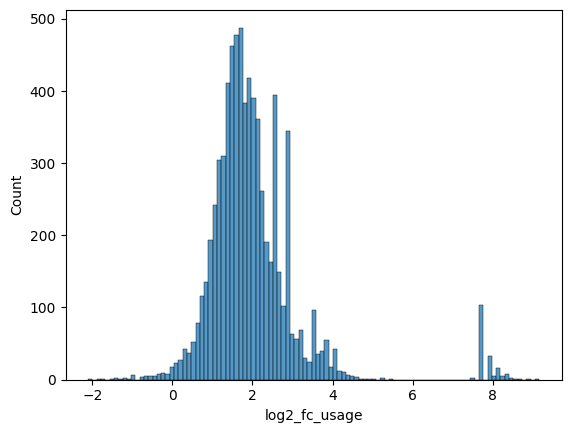

In [71]:
sns.histplot(summary, x='log2_fc_usage')

Now, we can calculate the TOPSIS scores. Below, you can see the metrics which are used and the example weights which you can tune based on your data.

In [72]:
metrics = {
    'n_patients': 'benefit',
    'sample_fraction': 'benefit',
    'log_cluster_size': 'benefit',
    'log_pgen': 'cost',
    'log2_fc_usage': 'benefit', 
    'vac_usage': 'benefit'
}

custom_weights = {
    'n_patients': 2,
    'sample_fraction': 1,
    'log_cluster_size': 1,
    'log_pgen': 2,
    'log2_fc_usage': 2,
    'vac_usage': 1
}

ranked_df = compute_topsis_score(summary[summary.n_patients > 1], metrics, weight_dict=custom_weights)
ranked_df.head(20)

,merged_cluster_id,cluster_size,n_patients,vdjdb,pgen,background,sample,sample_fraction,background_fraction,log_cluster_size,log_pgen,vac_usage,h_usage,log2_fc_usage,topsis_score
0,0,160,6,True,4.180945e-09,63,97,0.606250,0.393750,2.204120,-8.378726,0.001435,0.000401,1.837597,0.589979
1,135,44,5,True,1.467074e-09,16,28,0.636364,0.363636,1.643453,-8.833548,0.000520,0.000125,2.057714,0.566240
2,188,1740,6,False,1.701140e-08,1018,722,0.414943,0.585057,3.240549,-7.769260,0.012219,0.004303,1.505624,0.562738
3,175,433,6,False,9.622388e-09,261,172,0.397229,0.602771,2.636488,-8.016717,0.003218,0.000986,1.705987,0.560019
4,186,1751,6,True,1.720137e-08,1042,709,0.404911,0.595089,3.243286,-7.764437,0.011971,0.004579,1.386305,0.556612
5,73,1599,6,False,2.165088e-08,927,672,0.420263,0.579737,3.203848,-7.664524,0.010756,0.004168,1.367590,0.550887
6,35,5640,6,False,4.455090e-07,3176,2464,0.436879,0.563121,3.751279,-6.351144,0.049456,0.018159,1.445432,0.539972
7,64,452,5,False,5.097803e-09,263,189,0.418142,0.581858,2.655138,-8.292617,0.003346,0.001033,1.695858,0.528629
8,460,143,6,False,8.088155e-08,67,76,0.531469,0.468531,2.155336,-7.092151,0.001210,0.000333,1.861463,0.525598
9,1366,438,5,True,7.228845e-09,234,204,0.465753,0.534247,2.641474,-8.140931,0.003156,0.000996,1.663645,0.523681


In [73]:
ranked_df

,merged_cluster_id,cluster_size,n_patients,vdjdb,pgen,background,sample,sample_fraction,background_fraction,log_cluster_size,log_pgen,vac_usage,h_usage,log2_fc_usage,topsis_score
0,0,160,6,True,4.180945e-09,63,97,0.606250,0.393750,2.204120,-8.378726,0.001435,0.000401,1.837597,0.589979
1,135,44,5,True,1.467074e-09,16,28,0.636364,0.363636,1.643453,-8.833548,0.000520,0.000125,2.057714,0.566240
2,188,1740,6,False,1.701140e-08,1018,722,0.414943,0.585057,3.240549,-7.769260,0.012219,0.004303,1.505624,0.562738
3,175,433,6,False,9.622388e-09,261,172,0.397229,0.602771,2.636488,-8.016717,0.003218,0.000986,1.705987,0.560019
4,186,1751,6,True,1.720137e-08,1042,709,0.404911,0.595089,3.243286,-7.764437,0.011971,0.004579,1.386305,0.556612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,1644,17,2,False,8.890504e-07,7,10,0.588235,0.411765,1.230449,-6.051074,0.000129,0.000056,1.197202,0.192284
843,1876,11,2,False,4.779748e-07,4,7,0.636364,0.363636,1.041393,-6.320595,0.000071,0.000041,0.794780,0.189121
844,29,19,2,False,2.714540e-06,6,13,0.684211,0.315789,1.278754,-5.566304,0.000254,0.000117,1.114058,0.189078
845,1396,7,2,True,3.206493e-07,2,5,0.714286,0.285714,0.845098,-6.493970,0.000020,0.000019,0.031009,0.185764


In [74]:
ranked_df[ranked_df.vdjdb].index

Index([  0,   1,   4,   9,  12,  15,  17,  19,  20,  21,
       ...
       806, 810, 817, 818, 820, 828, 833, 834, 835, 845],
      dtype='int64', length=135)

In [75]:
pd.Series(ranked_df[ranked_df.vdjdb].index).describe()

count    135.000000
mean     375.318519
std      283.792142
min        0.000000
25%       91.000000
50%      312.000000
75%      660.500000
max      845.000000
dtype: float64

In [76]:
ranked_df = ranked_df.reset_index()
ranked_df

,index,merged_cluster_id,cluster_size,n_patients,vdjdb,pgen,background,sample,sample_fraction,background_fraction,log_cluster_size,log_pgen,vac_usage,h_usage,log2_fc_usage,topsis_score
0,0,0,160,6,True,4.180945e-09,63,97,0.606250,0.393750,2.204120,-8.378726,0.001435,0.000401,1.837597,0.589979
1,1,135,44,5,True,1.467074e-09,16,28,0.636364,0.363636,1.643453,-8.833548,0.000520,0.000125,2.057714,0.566240
2,2,188,1740,6,False,1.701140e-08,1018,722,0.414943,0.585057,3.240549,-7.769260,0.012219,0.004303,1.505624,0.562738
3,3,175,433,6,False,9.622388e-09,261,172,0.397229,0.602771,2.636488,-8.016717,0.003218,0.000986,1.705987,0.560019
4,4,186,1751,6,True,1.720137e-08,1042,709,0.404911,0.595089,3.243286,-7.764437,0.011971,0.004579,1.386305,0.556612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,842,1644,17,2,False,8.890504e-07,7,10,0.588235,0.411765,1.230449,-6.051074,0.000129,0.000056,1.197202,0.192284
843,843,1876,11,2,False,4.779748e-07,4,7,0.636364,0.363636,1.041393,-6.320595,0.000071,0.000041,0.794780,0.189121
844,844,29,19,2,False,2.714540e-06,6,13,0.684211,0.315789,1.278754,-5.566304,0.000254,0.000117,1.114058,0.189078
845,845,1396,7,2,True,3.206493e-07,2,5,0.714286,0.285714,0.845098,-6.493970,0.000020,0.000019,0.031009,0.185764


In [86]:
ranked_df[['vdjdb', 'merged_cluster_id', 'cluster_size', 'n_patients', 'log_pgen', 'sample_fraction', 'vac_usage', 'log2_fc_usage', 'topsis_score']]

,vdjdb,merged_cluster_id,cluster_size,n_patients,log_pgen,sample_fraction,vac_usage,log2_fc_usage,topsis_score
0,True,0,160,6,-8.378726,0.606250,0.001435,1.837597,0.589979
1,True,135,44,5,-8.833548,0.636364,0.000520,2.057714,0.566240
2,False,188,1740,6,-7.769260,0.414943,0.012219,1.505624,0.562738
3,False,175,433,6,-8.016717,0.397229,0.003218,1.705987,0.560019
4,True,186,1751,6,-7.764437,0.404911,0.011971,1.386305,0.556612
...,...,...,...,...,...,...,...,...,...
842,False,1644,17,2,-6.051074,0.588235,0.000129,1.197202,0.192284
843,False,1876,11,2,-6.320595,0.636364,0.000071,0.794780,0.189121
844,False,29,19,2,-5.566304,0.684211,0.000254,1.114058,0.189078
845,True,1396,7,2,-6.493970,0.714286,0.000020,0.031009,0.185764


<Axes: xlabel='index'>

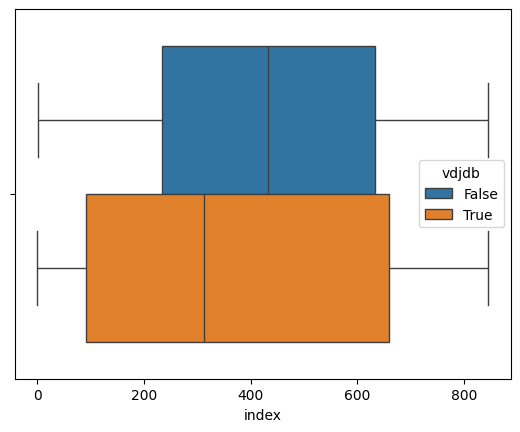

In [77]:
sns.boxplot(ranked_df, x='index', hue='vdjdb')

In [78]:
ranked_df[ranked_df.vdjdb]['index'].describe()

count    135.000000
mean     375.318519
std      283.792142
min        0.000000
25%       91.000000
50%      312.000000
75%      660.500000
max      845.000000
Name: index, dtype: float64

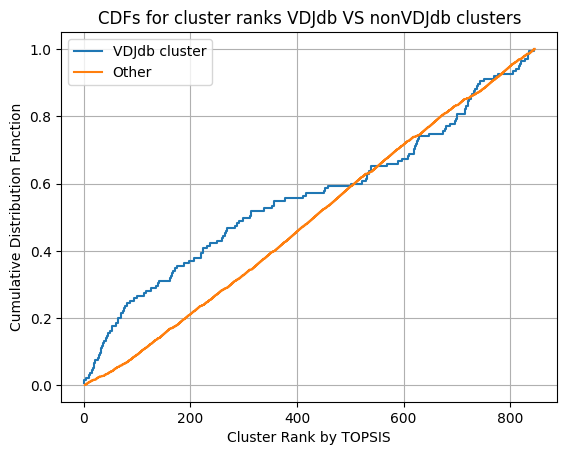

In [79]:
def plot_ecdf(data, label):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    plt.step(x, y, where='post', label=label)

plot_ecdf(ranked_df[ranked_df.vdjdb]['index'], "VDJdb cluster")
plot_ecdf(ranked_df[~ranked_df.vdjdb]['index'], "Other")
plt.xlabel("Cluster Rank by TOPSIS")
plt.ylabel("Cumulative Distribution Function")
plt.legend()
plt.title("CDFs for cluster ranks VDJdb VS nonVDJdb clusters")
plt.grid(True)
plt.show()

In [80]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import logomaker
from matplotlib import gridspec

def plot_bar(data, title, ax):
    counts = data.value_counts().reset_index()
    counts.columns = ['segment', 'count']

    if counts.empty:
        ax.axis('off')
        return

    # Используем 'segment' как hue и отключаем легенду
    sns.barplot(data=counts, y='segment', x='count', hue='segment', dodge=False,
                ax=ax, palette='pastel', legend=False)

    # Подписи на барах
    for i, (count, segment) in enumerate(zip(counts['count'], counts['segment'])):
        ax.text(count - 0.05, i, str(count), va='center')

    # ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel("")


def plot_logo(clonotypes, ax):
    try:
        mat_df = logomaker.alignment_to_matrix(clonotypes)
        logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=ax)
    except Exception:
        ax.axis('off')

def get_cluster_info(df, cluster_id):
    subset = df[df.merged_cluster_id == cluster_id]

    fig = plt.figure(figsize=(8, 4))
    gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])

    ax_logo = fig.add_subplot(gs[0, :])      # Логотип — вся первая строка
    ax_v = fig.add_subplot(gs[1, 0])         # V-бета barplot
    ax_j = fig.add_subplot(gs[1, 1])         # J-бета barplot

    plot_logo(subset.cdr3aa_beta.dropna(), ax_logo)
    plot_bar(subset.v_beta.dropna(), 'Vβ usage', ax_v)
    plot_bar(subset.j_beta.dropna(), 'Jβ usage', ax_j)
    plt.suptitle(f'Cluster #{cluster_id}')
    plt.tight_layout()
    plt.show()


## 5. Top cluster vizualizations
Here we would go through top clusters ranked by TcrEmpNet algorithm and vizualize their logos and VJ gene usage distributions.

   merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
0                  0           160           6   True  4.180945e-09   

   background  sample  sample_fraction  background_fraction  log_cluster_size  \
0          63      97          0.60625              0.39375           2.20412   

   log_pgen  vac_usage   h_usage  log2_fc_usage  
0 -8.378726   0.001435  0.000401       1.837597  


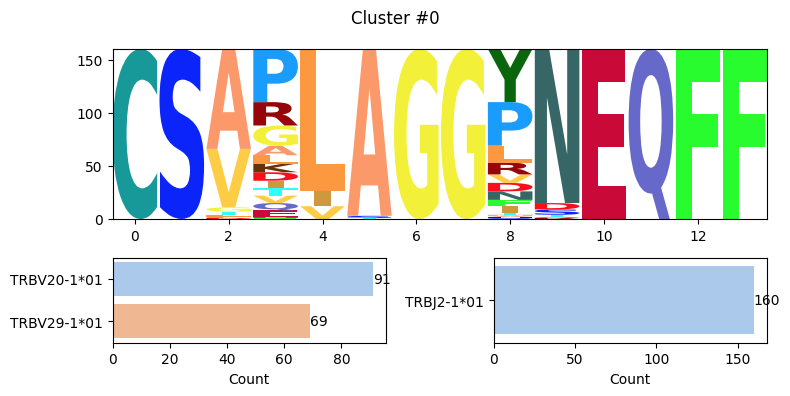

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
135                135            44           5   True  1.467074e-09   

     background  sample  sample_fraction  background_fraction  \
135          16      28         0.636364             0.363636   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
135          1.643453 -8.833548    0.00052  0.000125       2.057714  


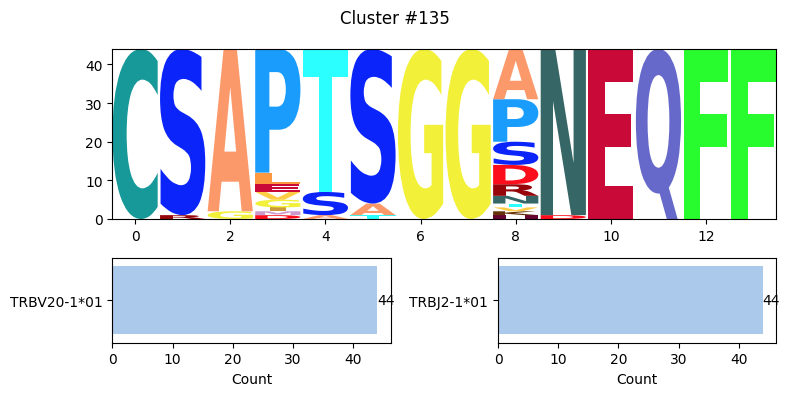

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
188                188          1740           6  False  1.701140e-08   

     background  sample  sample_fraction  background_fraction  \
188        1018     722         0.414943             0.585057   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
188          3.240549  -7.76926   0.012219  0.004303       1.505624  


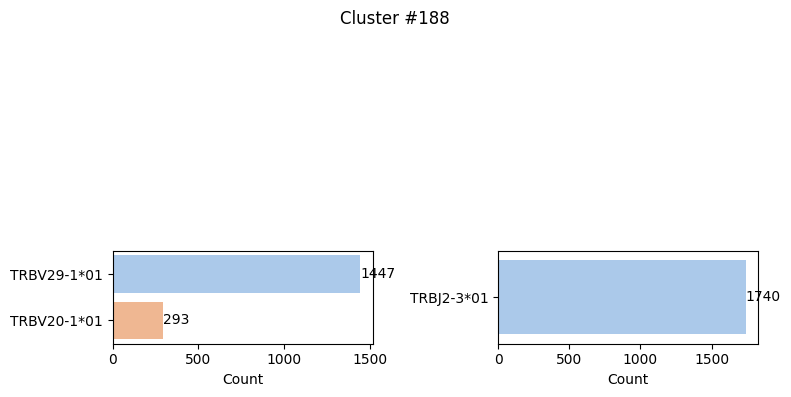

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
175                175           433           6  False  9.622388e-09   

     background  sample  sample_fraction  background_fraction  \
175         261     172         0.397229             0.602771   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
175          2.636488 -8.016717   0.003218  0.000986       1.705987  


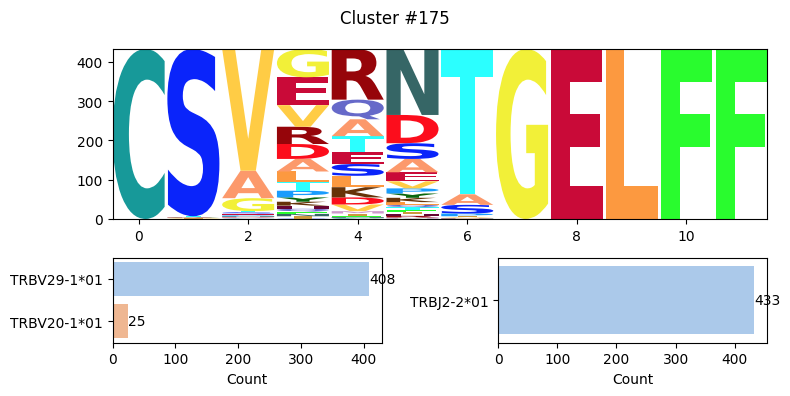

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
186                186          1751           6   True  1.720137e-08   

     background  sample  sample_fraction  background_fraction  \
186        1042     709         0.404911             0.595089   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
186          3.243286 -7.764437   0.011971  0.004579       1.386305  


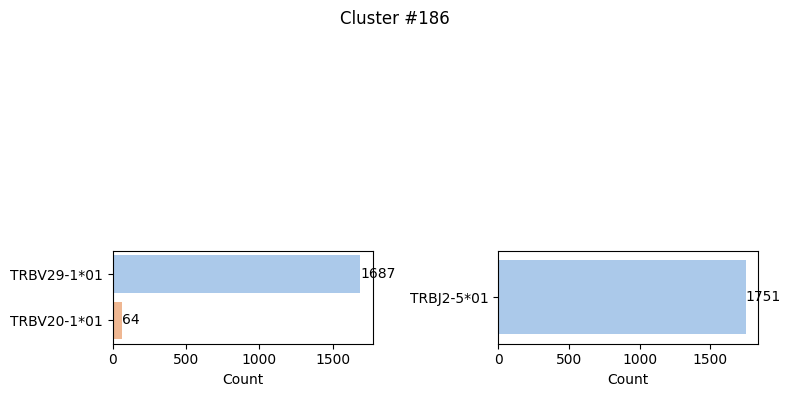

    merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
73                 73          1599           6  False  2.165088e-08   

    background  sample  sample_fraction  background_fraction  \
73         927     672         0.420263             0.579737   

    log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
73          3.203848 -7.664524   0.010756  0.004168        1.36759  


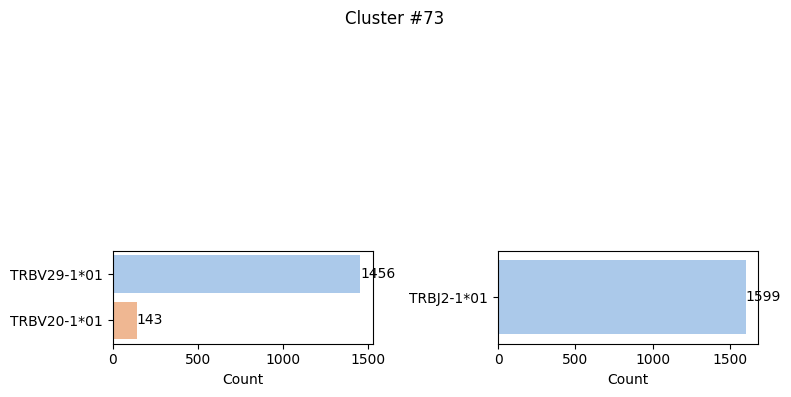

    merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
35                 35          5640           6  False  4.455090e-07   

    background  sample  sample_fraction  background_fraction  \
35        3176    2464         0.436879             0.563121   

    log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
35          3.751279 -6.351144   0.049456  0.018159       1.445432  


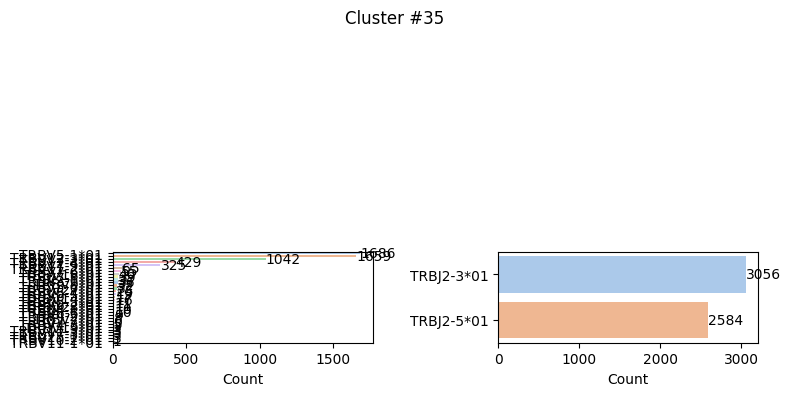

    merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
64                 64           452           5  False  5.097803e-09   

    background  sample  sample_fraction  background_fraction  \
64         263     189         0.418142             0.581858   

    log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
64          2.655138 -8.292617   0.003346  0.001033       1.695858  


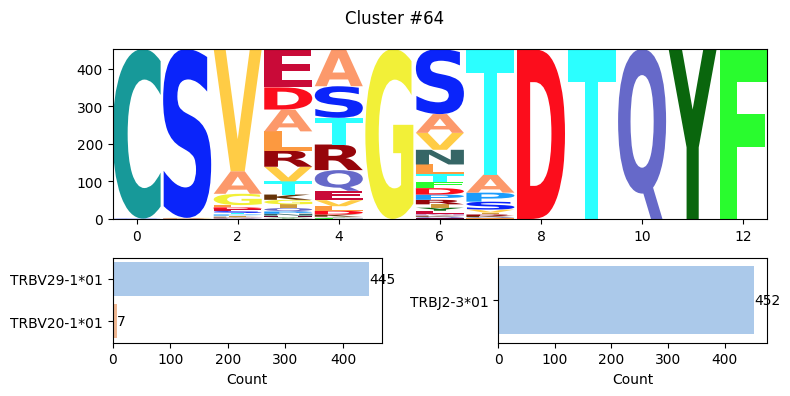

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
460                460           143           6  False  8.088155e-08   

     background  sample  sample_fraction  background_fraction  \
460          67      76         0.531469             0.468531   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
460          2.155336 -7.092151    0.00121  0.000333       1.861463  


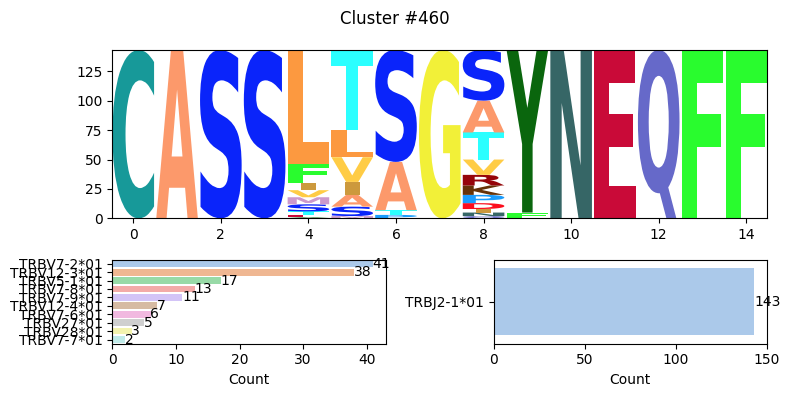

      merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
1366               1366           438           5   True  7.228845e-09   

      background  sample  sample_fraction  background_fraction  \
1366         234     204         0.465753             0.534247   

      log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
1366          2.641474 -8.140931   0.003156  0.000996       1.663645  


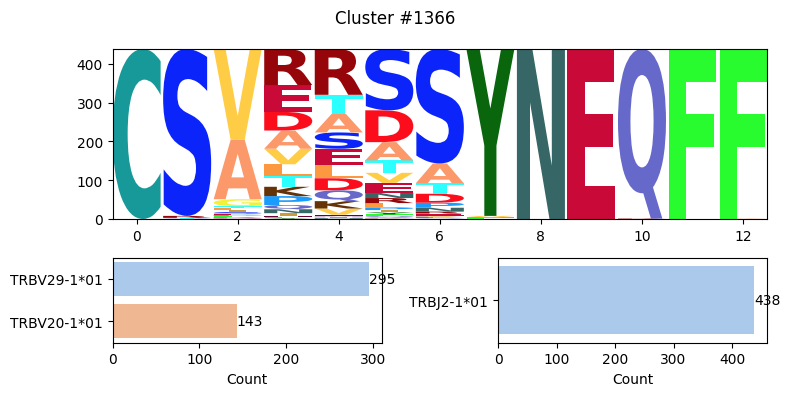

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
144                144           519           5  False  7.734815e-09   

     background  sample  sample_fraction  background_fraction  \
144         301     218         0.420039             0.579961   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
144          2.715167  -8.11155   0.003679  0.001148       1.679572  


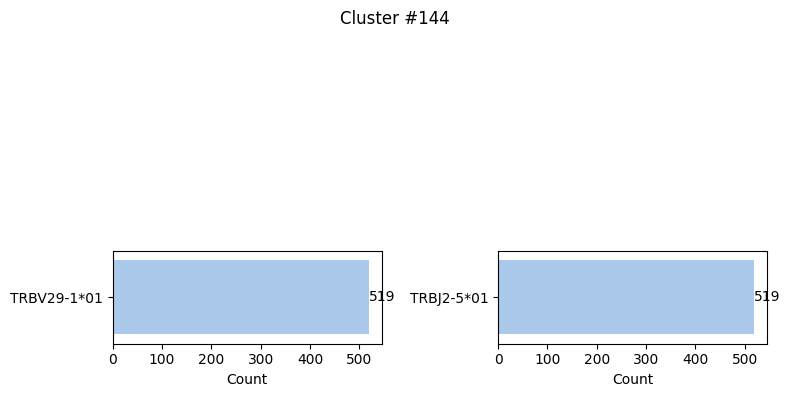

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
652                652           116           5  False  4.148083e-08   

     background  sample  sample_fraction  background_fraction  \
652          20      96         0.827586             0.172414   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
652          2.064458 -7.382153    0.00149  0.000371       2.003775  


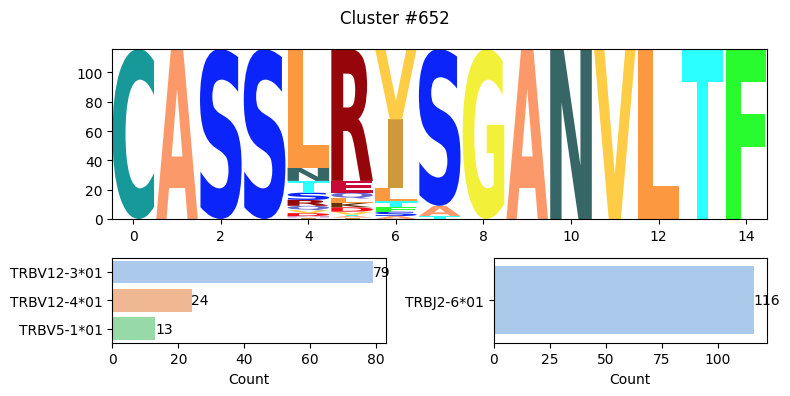

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
805                805            50           6   True  1.699896e-07   

     background  sample  sample_fraction  background_fraction  \
805          16      34             0.68                 0.32   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
805           1.69897 -6.769578   0.000425  0.000116       1.875433  


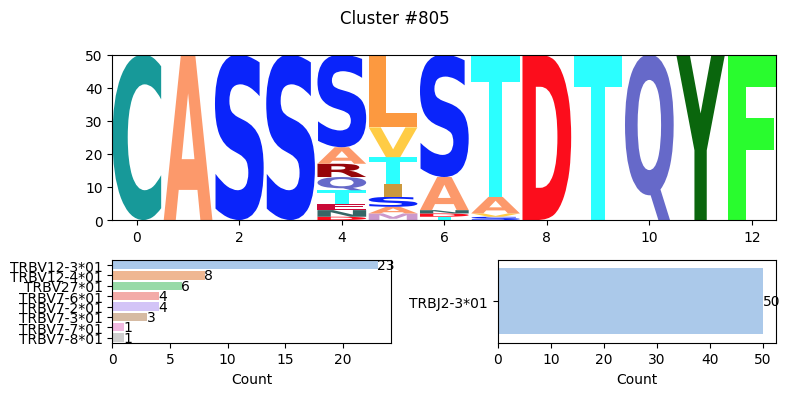

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
291                291           463           6  False  1.165688e-07   

     background  sample  sample_fraction  background_fraction  \
291         248     215         0.464363             0.535637   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
291          2.665581 -6.933418   0.003983  0.001353       1.557414  


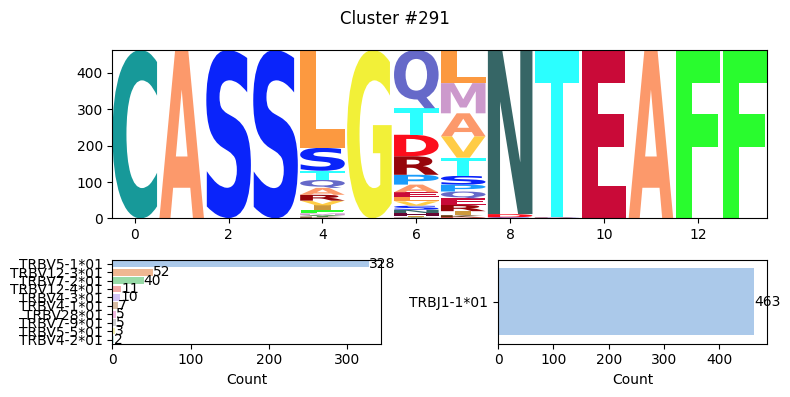

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
987                987            99           5  False  8.990665e-09   

     background  sample  sample_fraction  background_fraction  \
987          41      58         0.585859             0.414141   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
987          1.995635 -8.046208   0.000714  0.000237       1.587639  


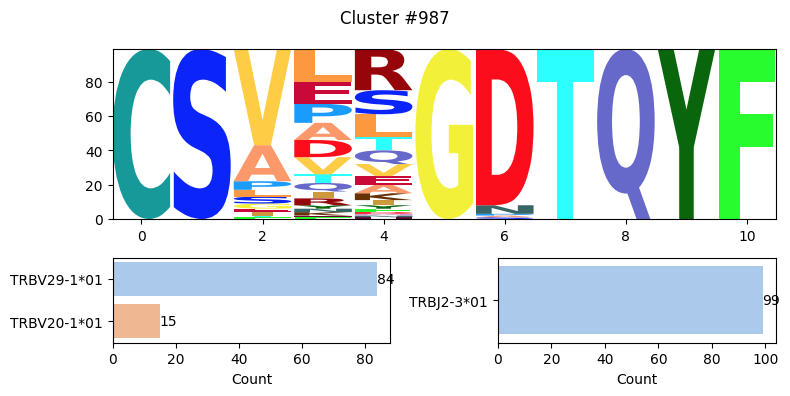

      merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
1313               1313           131           6   True  1.183680e-07   

      background  sample  sample_fraction  background_fraction  \
1313          63      68         0.519084             0.480916   

      log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
1313          2.117271 -6.926766   0.001247  0.000396       1.652993  


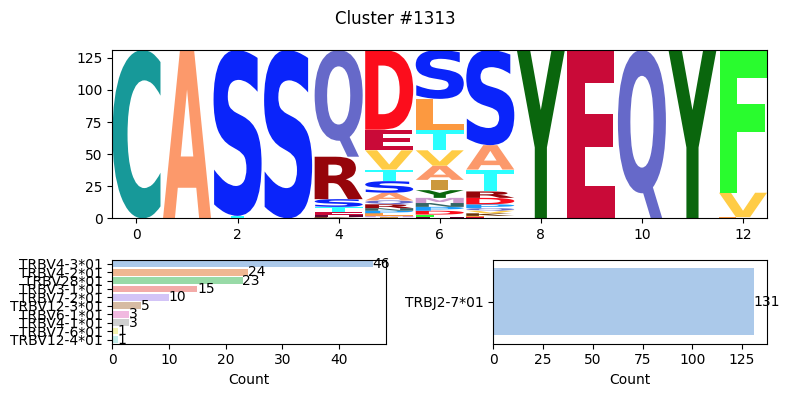

      merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
1425               1425           588           5  False  1.149817e-08   

      background  sample  sample_fraction  background_fraction  \
1425         347     241         0.409864             0.590136   

      log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
1425          2.769377 -7.939371   0.004334  0.001446       1.583522  


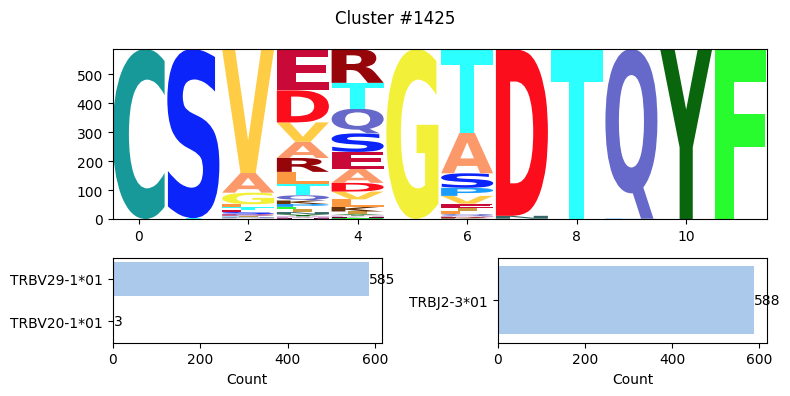

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
104                104           874           6   True  1.570387e-07   

     background  sample  sample_fraction  background_fraction  \
104         462     412         0.471396             0.528604   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
104          2.941511 -6.803993   0.007359  0.002884        1.35127  


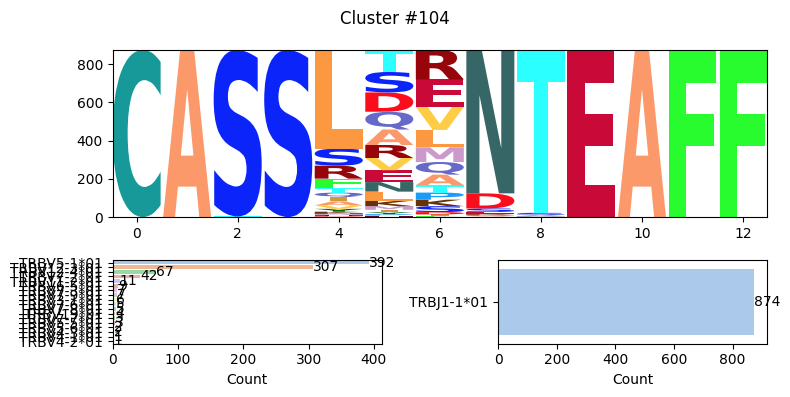

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
269                269           567           6  False  1.519353e-07   

     background  sample  sample_fraction  background_fraction  \
269         283     284         0.500882             0.499118   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
269          2.753583 -6.818341    0.00453  0.001684       1.427756  


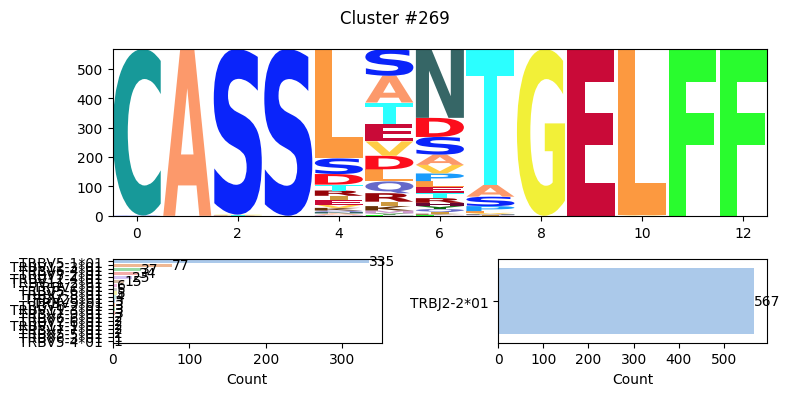

     merged_cluster_id  cluster_size  n_patients  vdjdb          pgen  \
100                100          1955           5   True  3.175656e-08   

     background  sample  sample_fraction  background_fraction  \
100        1160     795          0.40665              0.59335   

     log_cluster_size  log_pgen  vac_usage   h_usage  log2_fc_usage  
100          3.291147 -7.498167   0.013327  0.004441       1.585546  


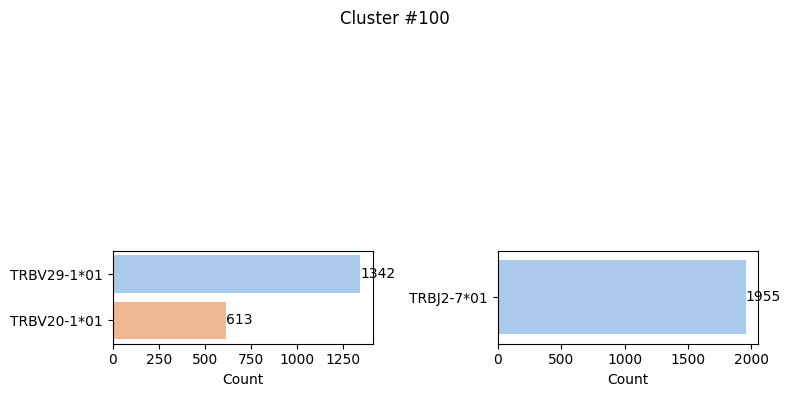

In [81]:
for cluster_id in ranked_df.head(20)['merged_cluster_id']:
    print(summary[summary.merged_cluster_id == cluster_id])
    get_cluster_info(df, cluster_id)